# Chapter 10 example: hidden variables, EM, and contrastive divergence

Hidden variables turn learning into an inference--learning loop. This notebook uses two deliberately small models so every quantity can be checked exactly.

**Part A** uses a two-component Bernoulli mixture. The E-step computes posterior responsibilities of the latent class; the M-step re-estimates mixture weights and Bernoulli parameters.

**Part B** uses a tiny Restricted Boltzmann Machine (RBM) to compare the exact likelihood gradient with a one-step contrastive-divergence approximation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

estimated mixture weights [0.56448495 0.43551505]
estimated Bernoulli probabilities
[[0.89583952 0.75811127 0.21929811 0.13481555]
 [0.22114522 0.30169091 0.7214665  0.84168233]]


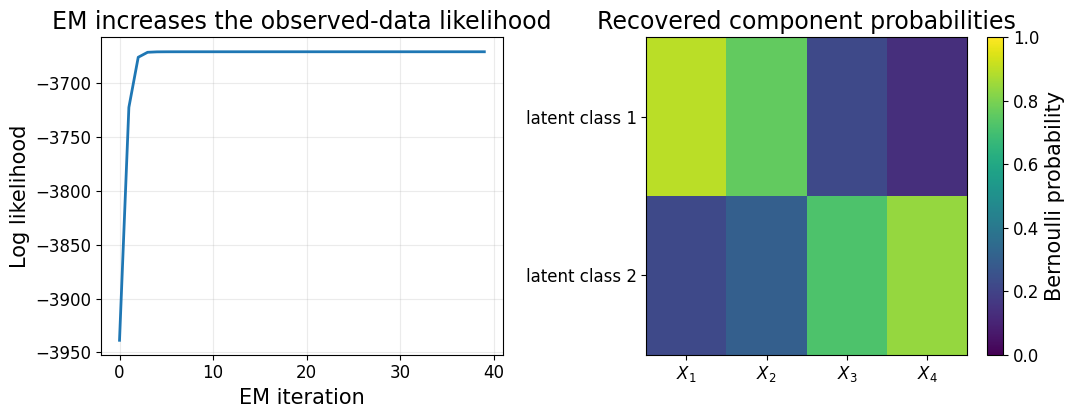

In [2]:
# Part A: two-component Bernoulli mixture
K=2; d=4; S=1500
pi_true=np.array([.58,.42]); q_true=np.array([[.85,.75,.20,.15],[.20,.30,.75,.85]])
z=RNG.choice(K,size=S,p=pi_true); X=np.vstack([RNG.binomial(1,q_true[k]) for k in z])
pi=np.array([.5,.5]); q=np.array([[.65,.55,.35,.25],[.35,.45,.65,.75]])
ll=[]
for it in range(40):
    logcomp=np.column_stack([np.log(pi[k])+np.sum(X*np.log(q[k])+(1-X)*np.log(1-q[k]),axis=1) for k in range(K)])
    mx=logcomp.max(1,keepdims=True); resp=np.exp(logcomp-mx); resp/=resp.sum(1,keepdims=True)
    ll.append(np.sum(mx[:,0]+np.log(np.exp(logcomp-mx).sum(1))))
    Nk=resp.sum(0); pi=Nk/S; q=(resp.T@X)/Nk[:,None]
print('estimated mixture weights',pi); print('estimated Bernoulli probabilities',q,sep='\n')
fig,axes=plt.subplots(1,2,figsize=(11,4.4)); axes[0].plot(ll,linewidth=2); axes[0].set_xlabel('EM iteration'); axes[0].set_ylabel('Log likelihood'); axes[0].set_title('EM increases the observed-data likelihood'); axes[0].grid(alpha=.25)
im=axes[1].imshow(q,vmin=0,vmax=1,aspect='auto'); axes[1].set_yticks([0,1],['latent class 1','latent class 2']); axes[1].set_xticks(range(d),[f'$X_{i+1}$' for i in range(d)]); axes[1].set_title('Recovered component probabilities'); fig.colorbar(im,ax=axes[1],label='Bernoulli probability'); fig.tight_layout(); save_figure(fig,'ch10_03_em_hidden_mixture'); plt.show()

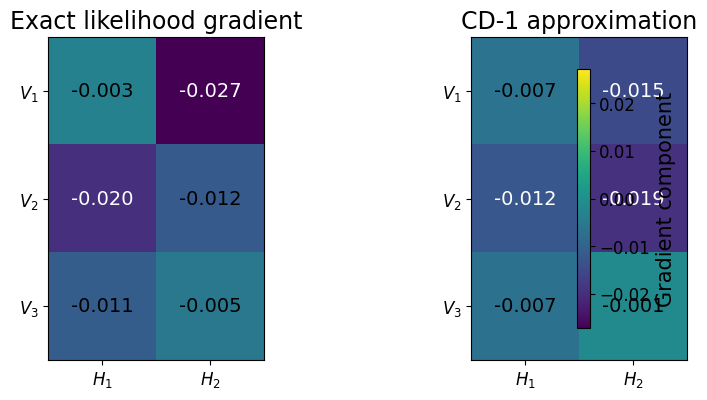

relative CD-1 gradient error 0.4636624693762494


In [3]:
# Part B: a 3-visible/2-hidden RBM. Exact enumeration makes the benchmark unambiguous.
vstates=np.array(list(product([-1,1],repeat=3)),float); hstates=np.array(list(product([-1,1],repeat=2)),float)
W=np.array([[.7,-.25],[-.5,.55],[.4,.65]]); bv=np.array([.15,-.05,.1]); bh=np.array([-.1,.2])
def joint_prob(W,bv,bh):
    pairs=[]; lw=[]
    for v in vstates:
      for h in hstates:
        pairs.append((v,h)); lw.append(v@W@h+bv@v+bh@h)
    lw=np.array(lw); pp=np.exp(lw-lw.max()); pp/=pp.sum(); return pairs,pp
pairs,pp=joint_prob(W,bv,bh); pv=np.array([sum(prob for (vv,hh),prob in zip(pairs,pp) if np.all(vv==v)) for v in vstates])
data=vstates[RNG.choice(len(vstates),size=3000,p=pv)]
def ph_given_v(v):
    m=np.tanh(bh+W.T@v); return m
# exact gradient of log likelihood w.r.t. W = data <v h> - model <v h>
data_pos=np.mean([np.outer(v,ph_given_v(v)) for v in data],axis=0)
model_neg=sum(prob*np.outer(v,h) for (v,h),prob in zip(pairs,pp))
g_exact=data_pos-model_neg
# CD-1: sample h|v, then v'|h, then use E[h|v'] for the negative phase
def sample_pm(mean): return np.where(RNG.random(len(mean))<(1+mean)/2,1.,-1.)
neg=[]
for v in data:
    h=sample_pm(np.tanh(bh+W.T@v)); vp=sample_pm(np.tanh(bv+W@h)); neg.append(np.outer(vp,ph_given_v(vp)))
g_cd1=data_pos-np.mean(neg,axis=0)
fig,axes=plt.subplots(1,2,figsize=(9.5,4.2)); vmax=max(abs(g_exact).max(),abs(g_cd1).max());
for ax,M,title in zip(axes,[g_exact,g_cd1],['Exact likelihood gradient','CD-1 approximation']):
 im=ax.imshow(M,vmin=-vmax,vmax=vmax); ax.set_xticks(range(2),['$H_1$','$H_2$']); ax.set_yticks(range(3),['$V_1$','$V_2$','$V_3$']); ax.set_title(title)
 for i in range(3):
  for j in range(2): ax.text(j,i,f'{M[i,j]:.3f}',ha='center',va='center',color='white' if abs(M[i,j])>.45*vmax else 'black')
fig.colorbar(im,ax=axes.ravel().tolist(),label='Gradient component',shrink=.8); fig.subplots_adjust(wspace=.35,right=.9); save_figure(fig,'ch10_03_exact_vs_cd_gradient'); plt.show()
print('relative CD-1 gradient error',np.linalg.norm(g_cd1-g_exact)/np.linalg.norm(g_exact))

## Exercises

1. Run EM from several random initializations and observe the label-switching symmetry of the latent components.
2. Replace CD-1 by CD-$k$ for $k=2,5,20$. Does the gradient approach the exact likelihood gradient monotonically?
3. **Challenge.** For the tiny RBM, perform exact maximum-likelihood learning by enumeration and compare its trajectory with CD-$k$. Identify when the CD fixed point differs visibly from the likelihood optimum.